In [37]:
import pandas as pd
df=pd.read_csv(r'/kaggle/input/datasets/johnfelix2911/predictive-maintenance-dataset/ai4i2020.csv')
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [38]:
df=df.drop(columns=['UDI','Product ID'])
all_tar=['Machine failure','TWF','HDF','PWF','OSF','RNF']

# EDA

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

## Correlation Heatmap

<Axes: >

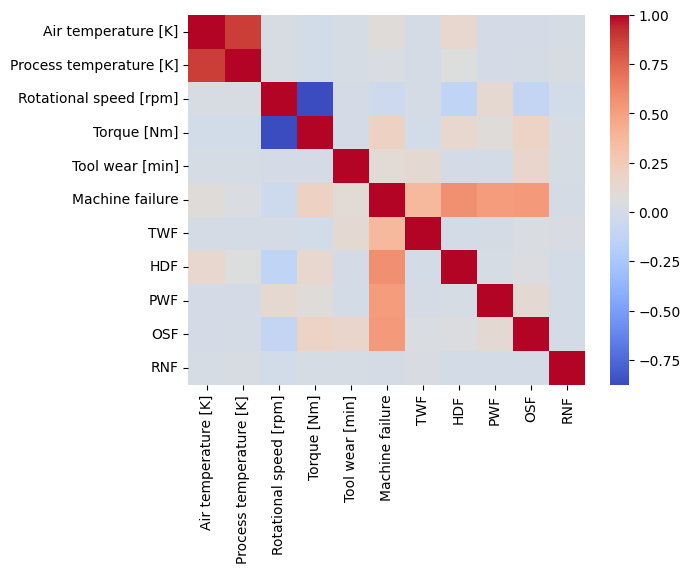

In [55]:
corr = df.drop(columns=['Type']).corr()
sns.heatmap(corr, annot=False, cmap='coolwarm')

## Target Imbalance Visualization

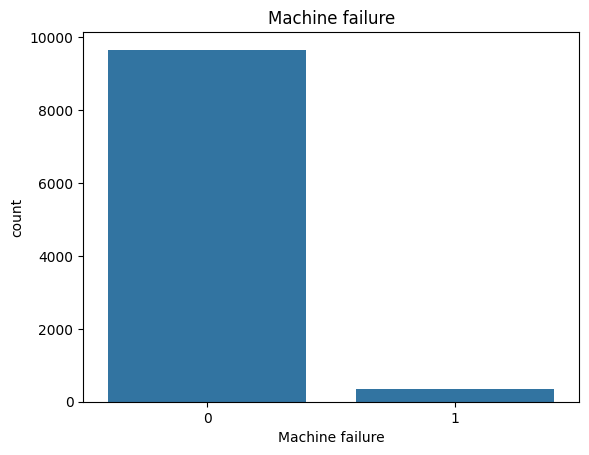

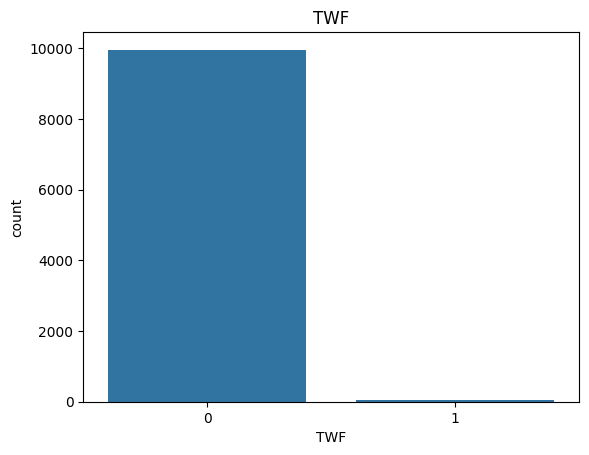

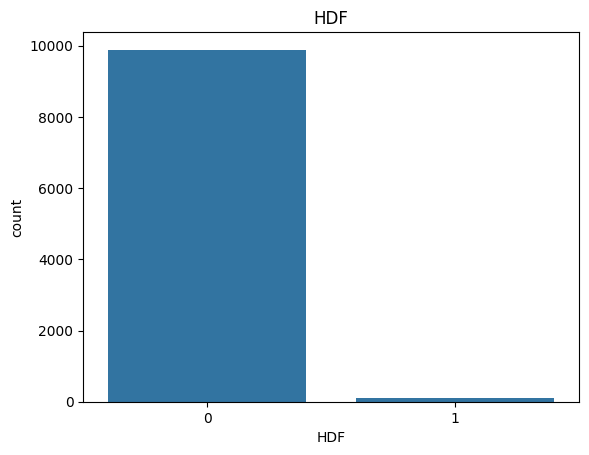

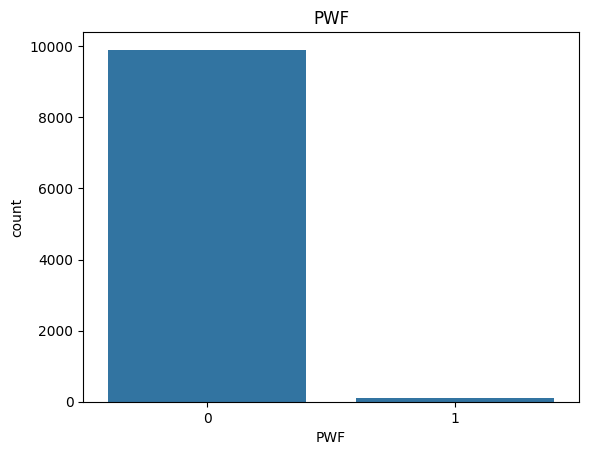

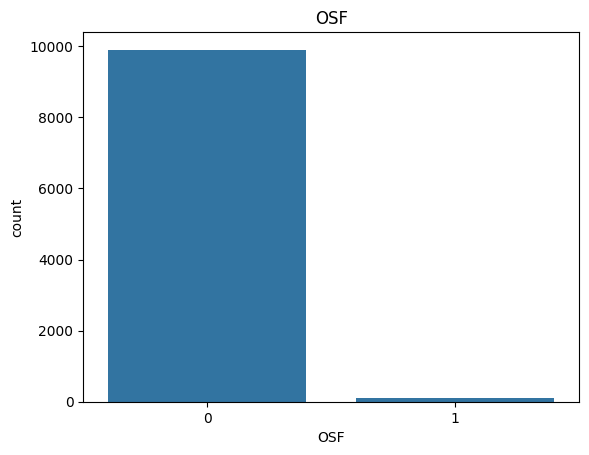

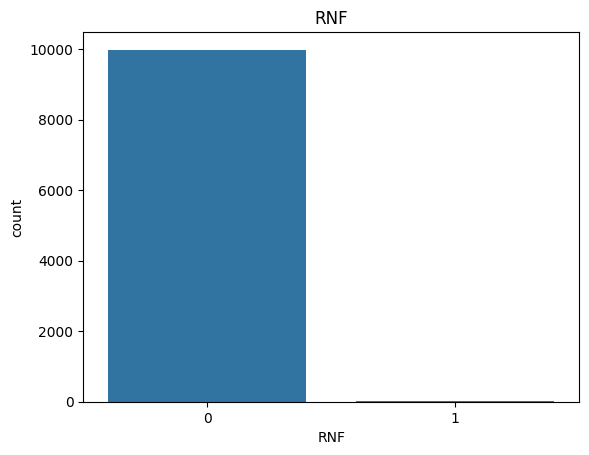

In [56]:
for col in all_tar:
    sns.countplot(x=df[col])
    plt.title(col)
    plt.show()

## Pairplot

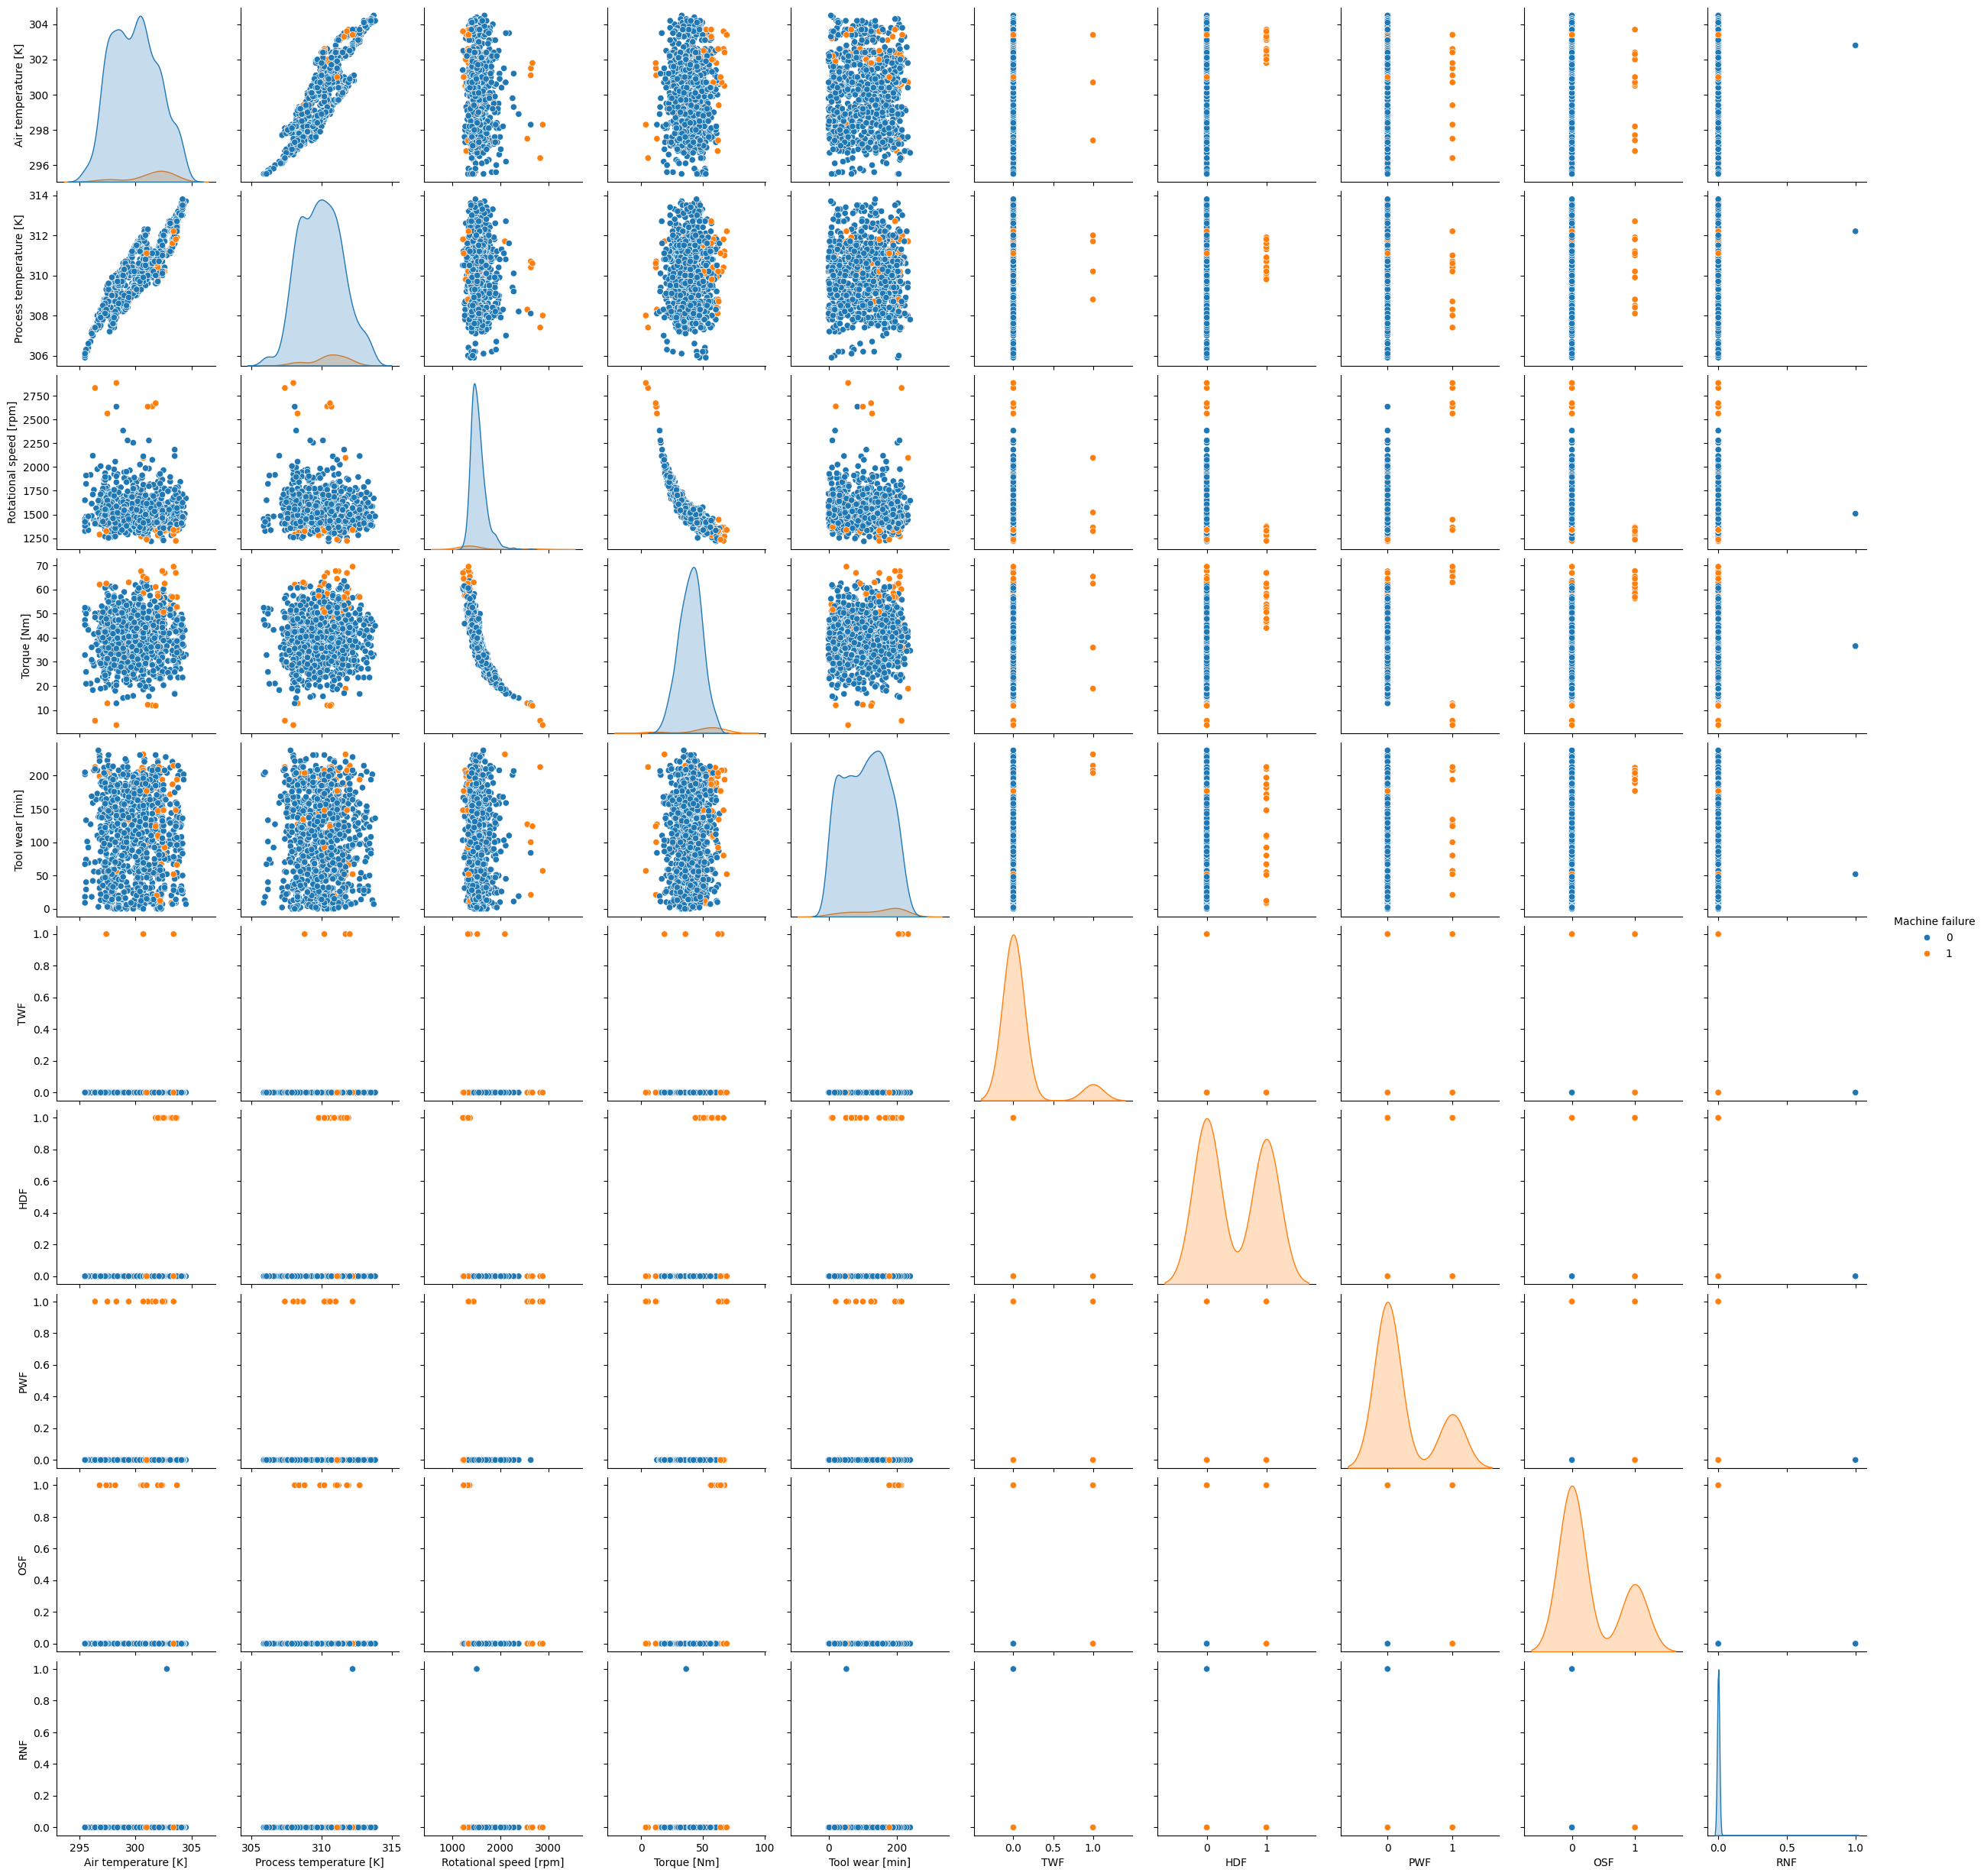

In [63]:
sns.pairplot(df.sample(1000), hue='Machine failure')

## Distribution of each feature for each target

In [44]:
def plot_classwise_feature_distribution(df,target):

    features = df.select_dtypes(include=['number']).columns.drop(target)

    for col in features:
        plt.figure()
        
        sns.histplot(
            data=df,
            x=col,
            hue=target,
            bins=30,
            kde=False,
            stat='density',
            common_norm=False
        )
        
        plt.title(f'Distribution of {col} by {target}')
        plt.show()

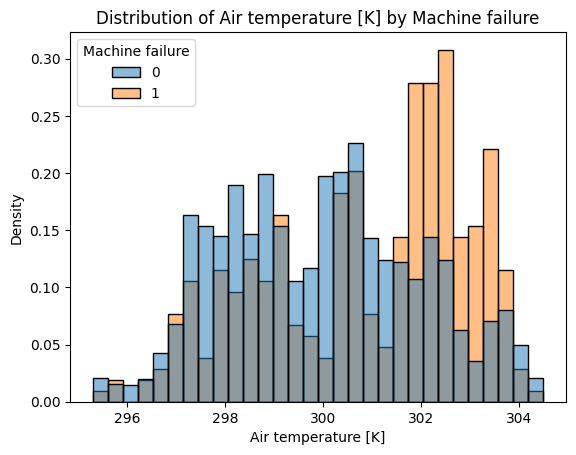

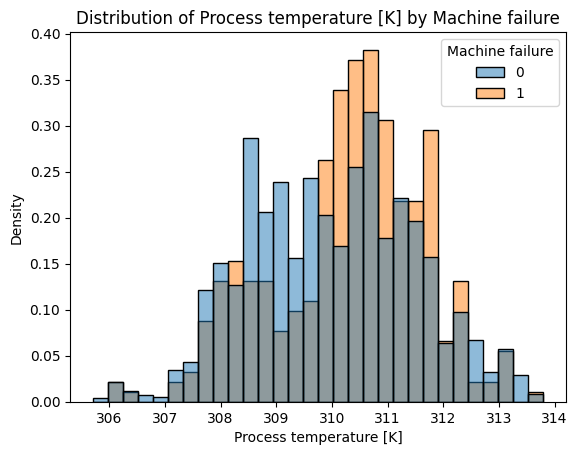

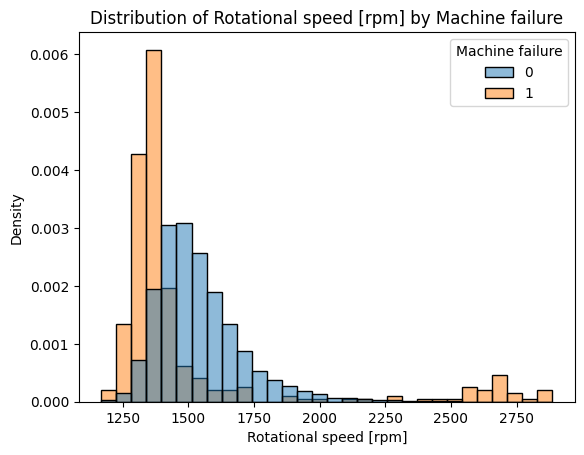

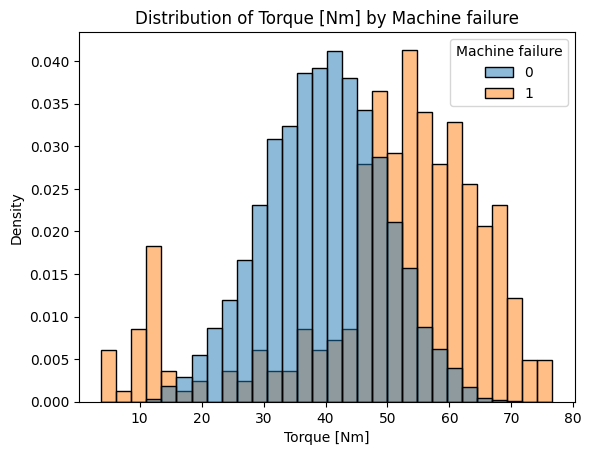

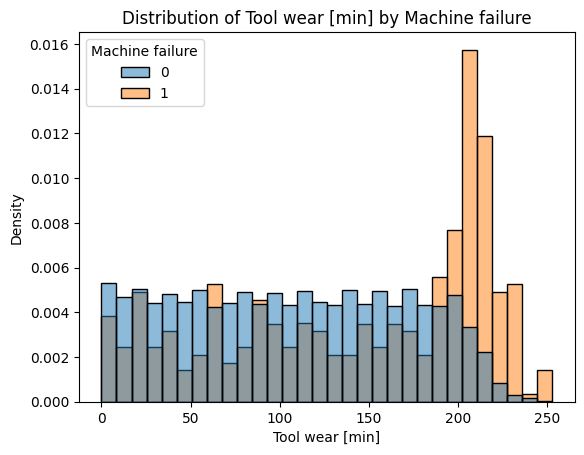

In [45]:
tar='Machine failure'
lis=all_tar.copy()
lis.remove(tar)
temp=df.drop(columns=lis)
plot_classwise_feature_distribution(temp,tar)

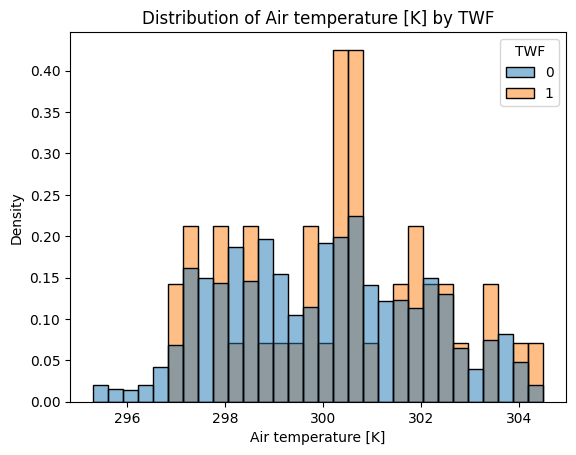

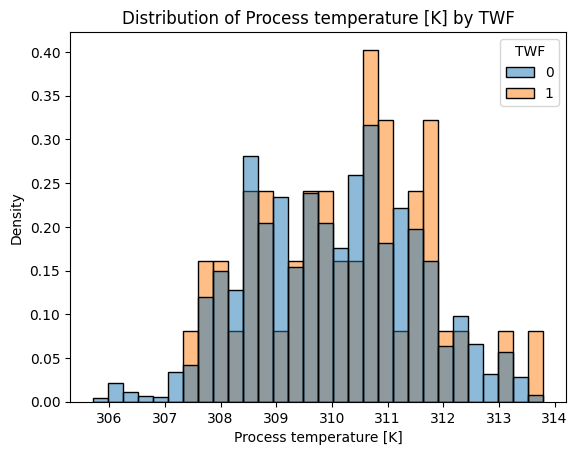

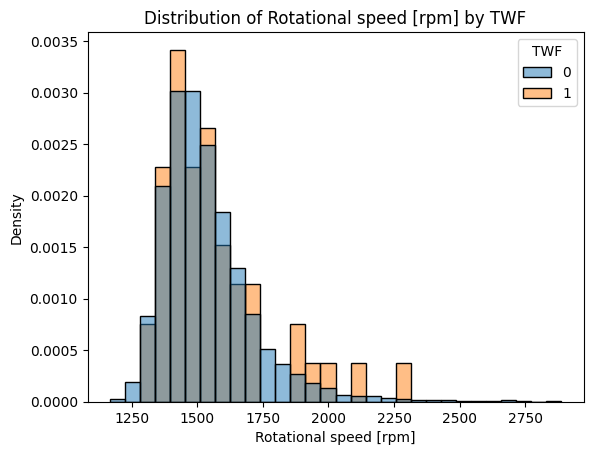

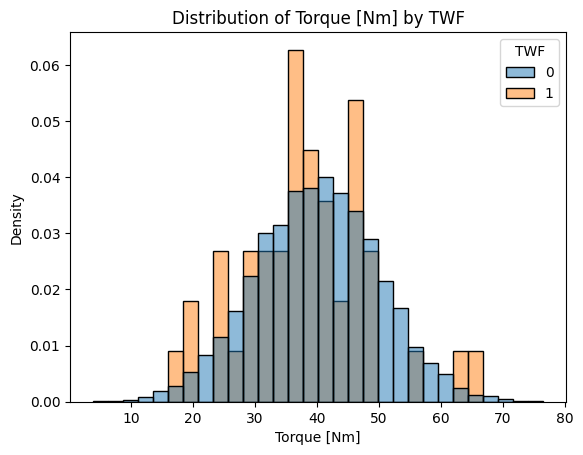

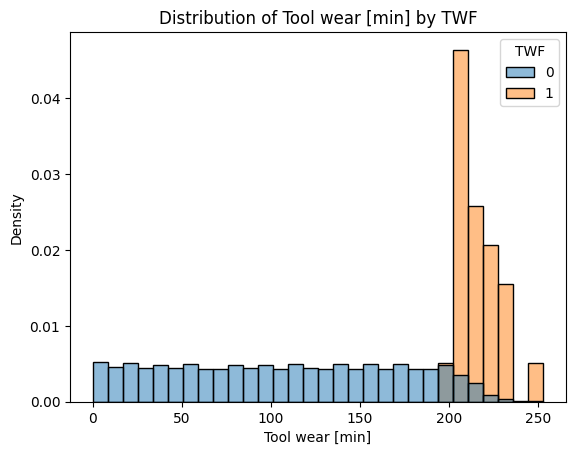

In [46]:
tar='TWF'
lis=all_tar.copy()
lis.remove(tar)
temp=df.drop(columns=lis)
plot_classwise_feature_distribution(temp,tar)

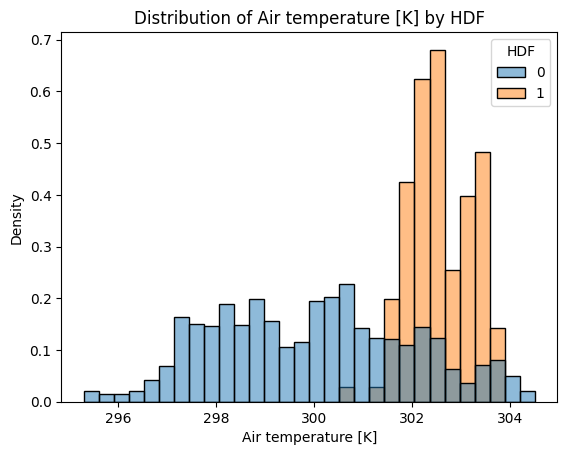

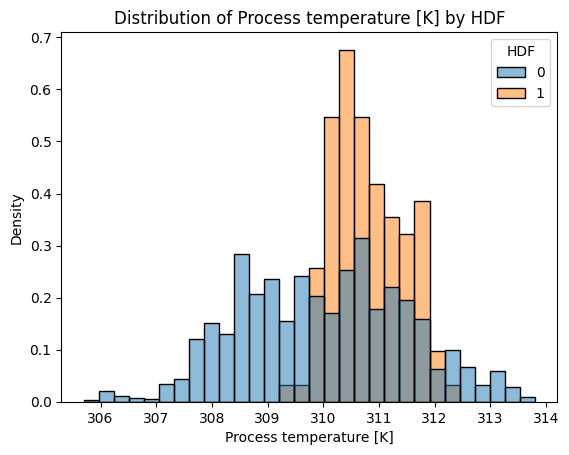

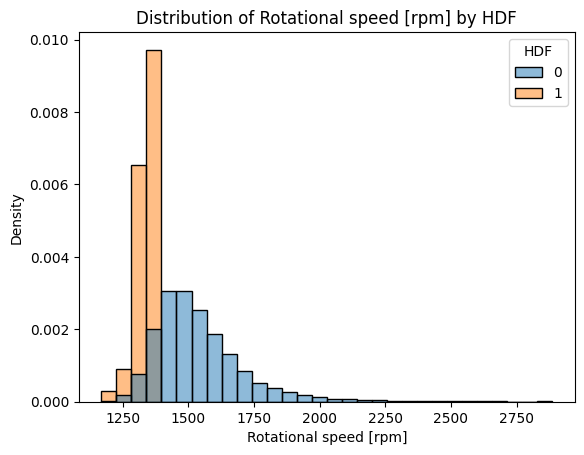

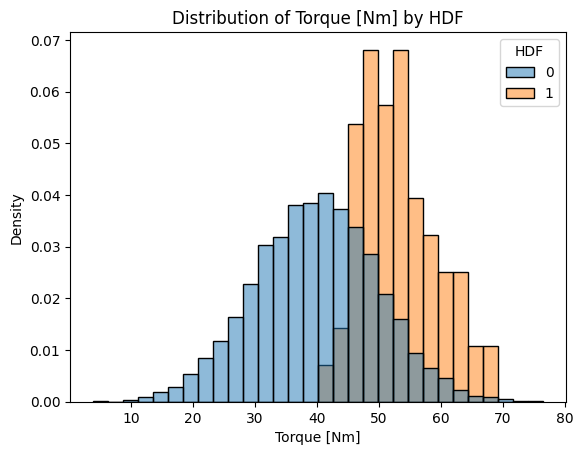

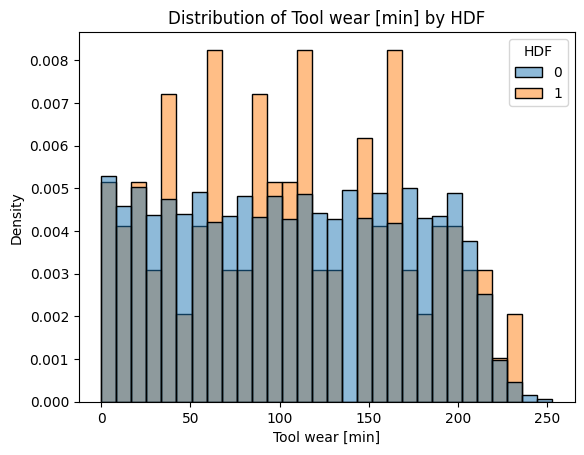

In [47]:
tar='HDF'
lis=all_tar.copy()
lis.remove(tar)
temp=df.drop(columns=lis)
plot_classwise_feature_distribution(temp,tar)

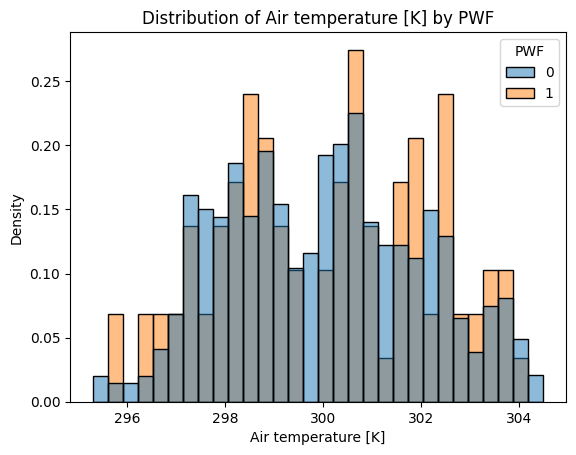

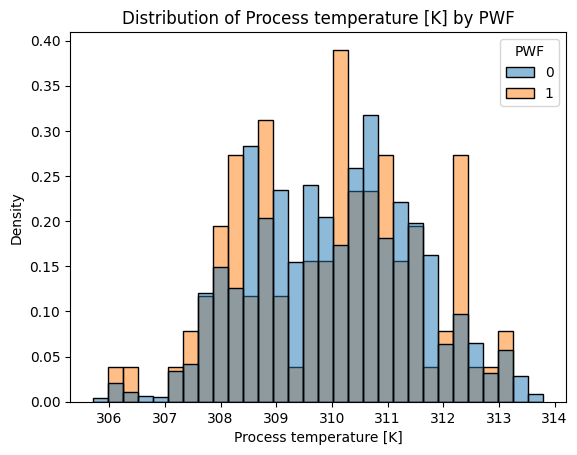

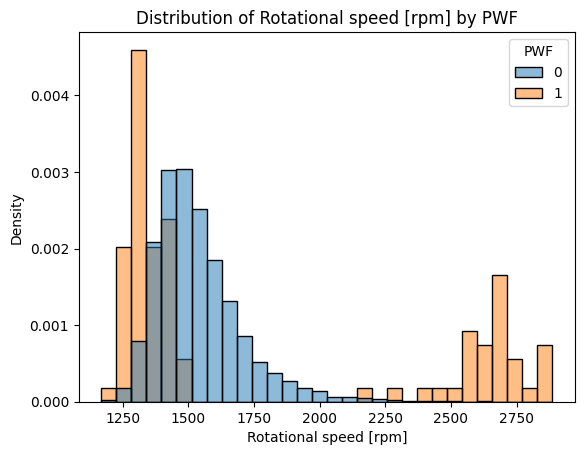

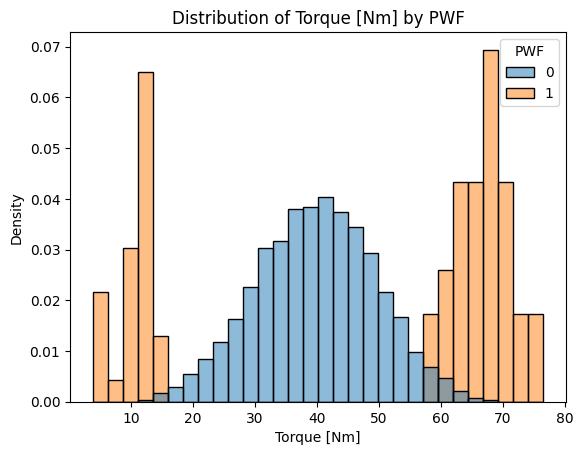

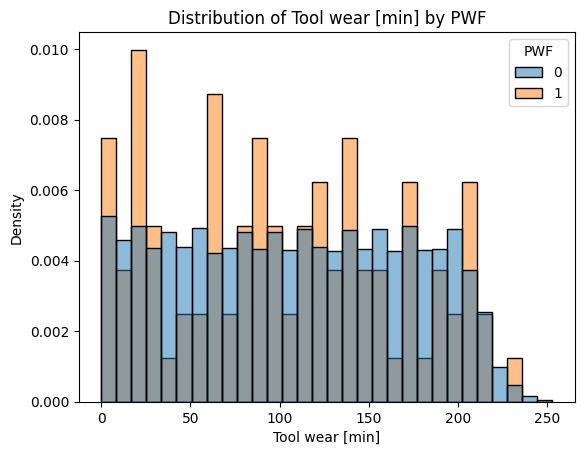

In [48]:
tar='PWF'
lis=all_tar.copy()
lis.remove(tar)
temp=df.drop(columns=lis)
plot_classwise_feature_distribution(temp,tar)

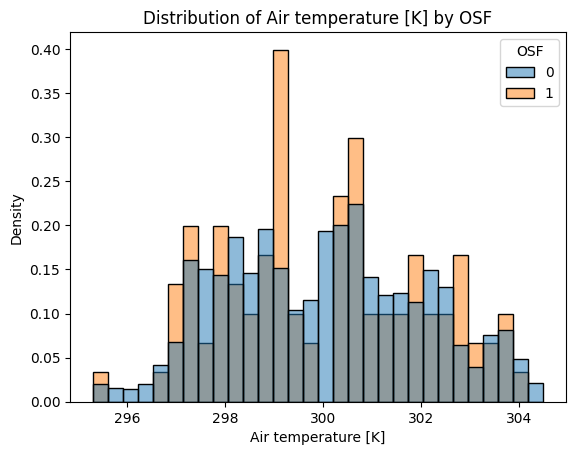

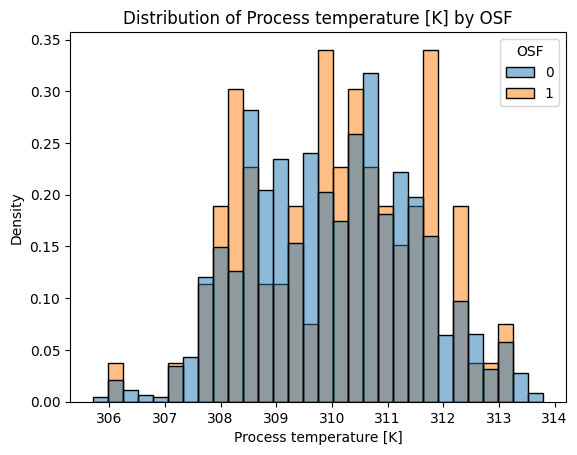

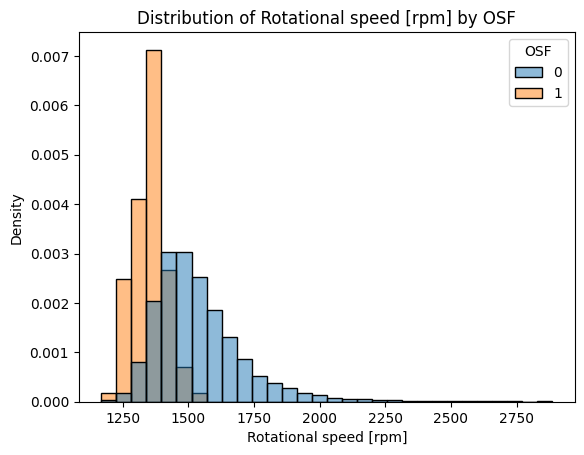

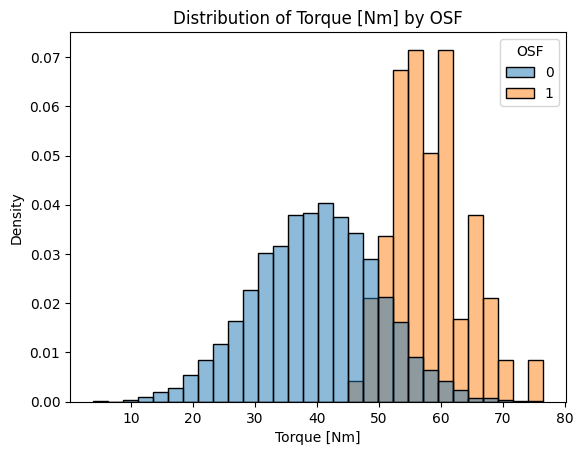

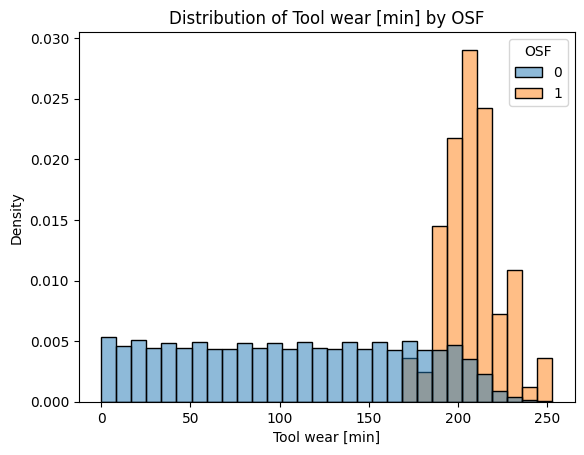

In [49]:
tar='OSF'
lis=all_tar.copy()
lis.remove(tar)
temp=df.drop(columns=lis)
plot_classwise_feature_distribution(temp,tar)

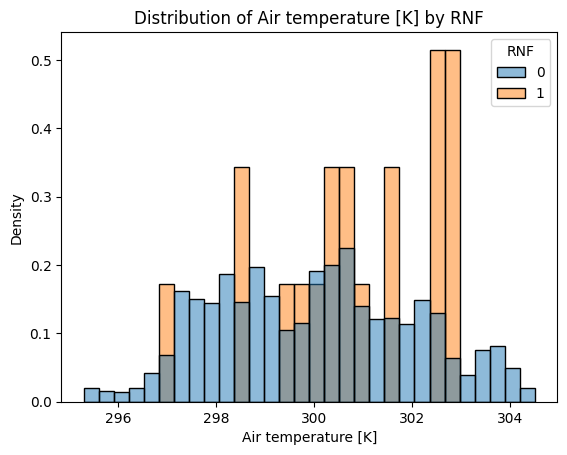

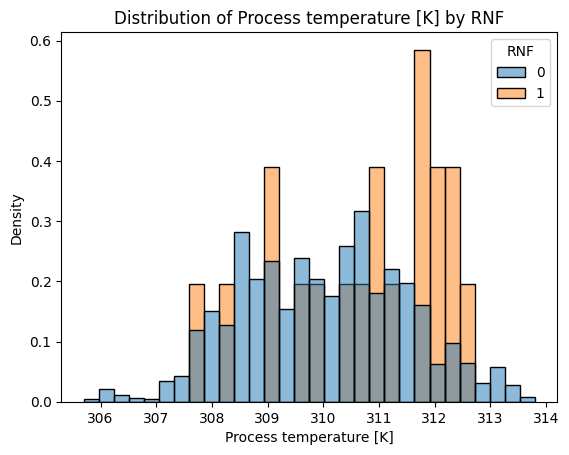

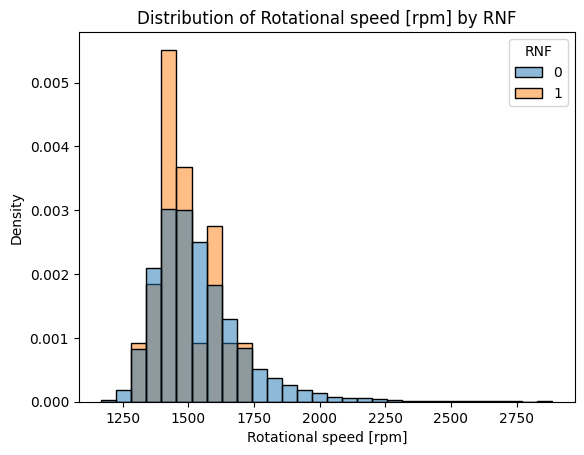

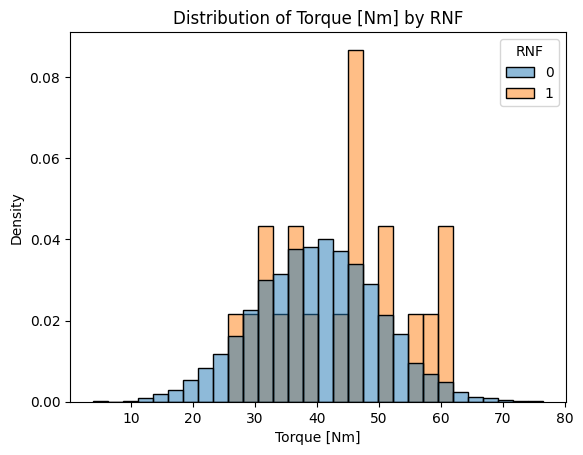

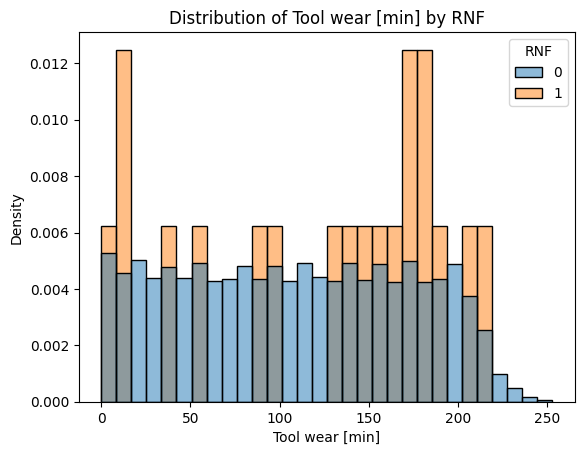

In [50]:
tar='RNF'
lis=all_tar.copy()
lis.remove(tar)
temp=df.drop(columns=lis)
plot_classwise_feature_distribution(temp,tar)

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTENC

train=df.sample(frac=0.8,random_state=42)
test=df.drop(train.index)

# Model-Wise

## Random Forest

In [4]:
def fit_RandomForest(df,tar):
    X_train=df.drop(columns=all_tar)
    y_train=df[tar]
    X_train = X_train.copy()
    X_train['Type'] = X_train['Type'].map({'L': 0, 'M': 1, 'H': 2})
    cat_index = [X_train.columns.get_loc('Type')]
    smote = SMOTENC(categorical_features=cat_index, random_state=42)
    X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
    rf = RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        random_state=42
    )
    rf.fit(X_resampled,y_resampled)
    return rf

In [5]:
def fit_and_eval_RF(target,train,test):
    model=fit_RandomForest(train,target)
    X_test=test.drop(columns=all_tar)
    y_test=test[target]
    X_test['Type'] = X_test['Type'].map({'L': 0, 'M': 1, 'H': 2})
    y_pred=model.predict(X_test)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))

In [6]:
for tar in all_tar:
    print("Target Name: ",tar)
    fit_and_eval_RF(tar,train,test)
    print("============================================")

Target Name:  Machine failure
Accuracy: 0.9645
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1925
           1       0.52      0.79      0.62        75

    accuracy                           0.96      2000
   macro avg       0.75      0.88      0.80      2000
weighted avg       0.97      0.96      0.97      2000

Target Name:  TWF
Accuracy: 0.984
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1988
           1       0.08      0.17      0.11        12

    accuracy                           0.98      2000
   macro avg       0.54      0.58      0.55      2000
weighted avg       0.99      0.98      0.99      2000

Target Name:  HDF
Accuracy: 0.9955
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1976
           1       0.76      0.92      0.83        24

    accuracy                           1.00      2000
   macro avg

## Logistic Regression

In [7]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTENC

def fit_LogisticRegression(df, tar):
    X_train = df.drop(columns=all_tar)
    y_train = df[tar]

    # Encode categorical column
    X_train = X_train.copy()
    X_train['Type'] = X_train['Type'].map({'L': 0, 'M': 1, 'H': 2})

    # Identify categorical column index
    cat_index = [X_train.columns.get_loc('Type')]

    # Apply SMOTENC
    smote = SMOTENC(categorical_features=cat_index, random_state=42)
    X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

    # 🔥 Logistic Regression model
    lr = LogisticRegression(
        max_iter=1000,       # important for convergence
        random_state=42
    )
    lr.fit(X_resampled, y_resampled)

    return lr


def fit_and_eval_LR(target, train, test):
    model = fit_LogisticRegression(train, target)

    X_test = test.drop(columns=all_tar).copy()
    y_test = test[target]

    # Same encoding
    X_test['Type'] = X_test['Type'].map({'L': 0, 'M': 1, 'H': 2})

    # 🔥 Direct classification (no thresholding needed)
    y_pred = model.predict(X_test)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))


for tar in all_tar:
    print("Target Name:", tar)
    fit_and_eval_LR(tar, train, test)
    print("============================================")

Target Name: Machine failure
Accuracy: 0.831
              precision    recall  f1-score   support

           0       0.99      0.83      0.90      1925
           1       0.16      0.83      0.27        75

    accuracy                           0.83      2000
   macro avg       0.58      0.83      0.59      2000
weighted avg       0.96      0.83      0.88      2000

Target Name: TWF
Accuracy: 0.9155
              precision    recall  f1-score   support

           0       1.00      0.91      0.96      1988
           1       0.07      1.00      0.12        12

    accuracy                           0.92      2000
   macro avg       0.53      0.96      0.54      2000
weighted avg       0.99      0.92      0.95      2000

Target Name: HDF
Accuracy: 0.9755
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1976
           1       0.33      1.00      0.49        24

    accuracy                           0.98      2000
   macro avg   

## Decision Tree

In [8]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTENC

def fit_DecisionTree(df, tar):
    X_train = df.drop(columns=all_tar)
    y_train = df[tar]

    # Encode categorical column
    X_train = X_train.copy()
    X_train['Type'] = X_train['Type'].map({'L': 0, 'M': 1, 'H': 2})

    # Identify categorical column index
    cat_index = [X_train.columns.get_loc('Type')]

    # Apply SMOTENC
    smote = SMOTENC(categorical_features=cat_index, random_state=42)
    X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

    # 🔥 Decision Tree model
    dt = DecisionTreeClassifier(
        max_depth=None,
        random_state=42
    )
    dt.fit(X_resampled, y_resampled)

    return dt


def fit_and_eval_DT(target, train, test):
    model = fit_DecisionTree(train, target)

    X_test = test.drop(columns=all_tar).copy()
    y_test = test[target]

    # Same encoding
    X_test['Type'] = X_test['Type'].map({'L': 0, 'M': 1, 'H': 2})

    y_pred = model.predict(X_test)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))


for tar in all_tar:
    print("Target Name:", tar)
    fit_and_eval_DT(tar, train, test)
    print("============================================")

Target Name: Machine failure
Accuracy: 0.946
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      1925
           1       0.39      0.77      0.52        75

    accuracy                           0.95      2000
   macro avg       0.69      0.86      0.74      2000
weighted avg       0.97      0.95      0.95      2000

Target Name: TWF
Accuracy: 0.9785
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1988
           1       0.00      0.00      0.00        12

    accuracy                           0.98      2000
   macro avg       0.50      0.49      0.49      2000
weighted avg       0.99      0.98      0.98      2000

Target Name: HDF
Accuracy: 0.998
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1976
           1       0.92      0.92      0.92        24

    accuracy                           1.00      2000
   macro avg    

## Neural Network

In [9]:
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTENC

def fit_NN(df, tar):
    X_train = df.drop(columns=all_tar)
    y_train = df[tar]

    # Encode categorical column
    X_train = X_train.copy()
    X_train['Type'] = X_train['Type'].map({'L': 0, 'M': 1, 'H': 2})

    # Identify categorical column index
    cat_index = [X_train.columns.get_loc('Type')]

    # Apply SMOTENC
    smote = SMOTENC(categorical_features=cat_index, random_state=42)
    X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

    # 🔥 Scale features (VERY IMPORTANT)
    scaler = StandardScaler()
    X_resampled = scaler.fit_transform(X_resampled)

    # 🔥 Neural Network
    nn = MLPClassifier(
        hidden_layer_sizes=(64, 32),  # 2-layer network
        activation='relu',
        solver='adam',
        max_iter=300,
        random_state=42
    )
    nn.fit(X_resampled, y_resampled)

    return nn, scaler


def fit_and_eval_NN(target, train, test):
    model, scaler = fit_NN(train, target)

    X_test = test.drop(columns=all_tar).copy()
    y_test = test[target]

    # Same encoding
    X_test['Type'] = X_test['Type'].map({'L': 0, 'M': 1, 'H': 2})

    # Apply SAME scaling
    X_test = scaler.transform(X_test)

    y_pred = model.predict(X_test)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))


for tar in all_tar:
    print("Target Name:", tar)
    fit_and_eval_NN(tar, train, test)
    print("============================================")

Target Name: Machine failure


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy: 0.9455
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      1925
           1       0.39      0.80      0.52        75

    accuracy                           0.95      2000
   macro avg       0.69      0.88      0.75      2000
weighted avg       0.97      0.95      0.95      2000

Target Name: TWF
Accuracy: 0.9825
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1988
           1       0.07      0.17      0.10        12

    accuracy                           0.98      2000
   macro avg       0.53      0.58      0.55      2000
weighted avg       0.99      0.98      0.99      2000

Target Name: HDF
Accuracy: 0.997
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1976
           1       0.85      0.92      0.88        24

    accuracy                           1.00      2000
   macro avg       0.92      0.96      0.94 

## Linear Discriminant Analysis

In [10]:
import pandas as pd
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTENC

def fit_LDA(df, tar):
    X_train = df.drop(columns=all_tar)
    y_train = df[tar]

    # Encode categorical column
    X_train = X_train.copy()
    X_train['Type'] = X_train['Type'].map({'L': 0, 'M': 1, 'H': 2})

    # Identify categorical column index
    cat_index = [X_train.columns.get_loc('Type')]

    # Apply SMOTENC
    smote = SMOTENC(categorical_features=cat_index, random_state=42)
    X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

    # 🔥 Scale features (important for LDA)
    scaler = StandardScaler()
    X_resampled = scaler.fit_transform(X_resampled)

    # 🔥 LDA model
    lda = LinearDiscriminantAnalysis()
    lda.fit(X_resampled, y_resampled)

    return lda, scaler


def fit_and_eval_LDA(target, train, test):
    model, scaler = fit_LDA(train, target)

    X_test = test.drop(columns=all_tar).copy()
    y_test = test[target]

    # Same encoding
    X_test['Type'] = X_test['Type'].map({'L': 0, 'M': 1, 'H': 2})

    # Apply same scaling
    X_test = scaler.transform(X_test)

    y_pred = model.predict(X_test)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))


for tar in all_tar:
    print("Target Name:", tar)
    fit_and_eval_LDA(tar, train, test)
    print("============================================")

Target Name: Machine failure
Accuracy: 0.8285
              precision    recall  f1-score   support

           0       0.99      0.83      0.90      1925
           1       0.16      0.83      0.27        75

    accuracy                           0.83      2000
   macro avg       0.58      0.83      0.58      2000
weighted avg       0.96      0.83      0.88      2000

Target Name: TWF
Accuracy: 0.7505
              precision    recall  f1-score   support

           0       1.00      0.75      0.86      1988
           1       0.02      1.00      0.05        12

    accuracy                           0.75      2000
   macro avg       0.51      0.87      0.45      2000
weighted avg       0.99      0.75      0.85      2000

Target Name: HDF
Accuracy: 0.865
              precision    recall  f1-score   support

           0       1.00      0.86      0.93      1976
           1       0.08      1.00      0.15        24

    accuracy                           0.86      2000
   macro avg   

## Quadratic Discriminant Analysis

In [11]:
import pandas as pd
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTENC

def fit_QDA(df, tar):
    X_train = df.drop(columns=all_tar)
    y_train = df[tar]

    # Encode categorical column
    X_train = X_train.copy()
    X_train['Type'] = X_train['Type'].map({'L': 0, 'M': 1, 'H': 2})

    # Identify categorical column index
    cat_index = [X_train.columns.get_loc('Type')]

    # Apply SMOTENC
    smote = SMOTENC(categorical_features=cat_index, random_state=42)
    X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

    # 🔥 Scale features (helps stability)
    scaler = StandardScaler()
    X_resampled = scaler.fit_transform(X_resampled)

    # 🔥 QDA model
    qda = QuadraticDiscriminantAnalysis()
    qda.fit(X_resampled, y_resampled)

    return qda, scaler


def fit_and_eval_QDA(target, train, test):
    model, scaler = fit_QDA(train, target)

    X_test = test.drop(columns=all_tar).copy()
    y_test = test[target]

    # Same encoding
    X_test['Type'] = X_test['Type'].map({'L': 0, 'M': 1, 'H': 2})

    # Apply same scaling
    X_test = scaler.transform(X_test)

    y_pred = model.predict(X_test)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))


for tar in all_tar:
    print("Target Name:", tar)
    fit_and_eval_QDA(tar, train, test)
    print("============================================")

Target Name: Machine failure
Accuracy: 0.8875
              precision    recall  f1-score   support

           0       0.99      0.89      0.94      1925
           1       0.22      0.81      0.35        75

    accuracy                           0.89      2000
   macro avg       0.61      0.85      0.64      2000
weighted avg       0.96      0.89      0.92      2000

Target Name: TWF
Accuracy: 0.912
              precision    recall  f1-score   support

           0       1.00      0.91      0.95      1988
           1       0.05      0.75      0.09        12

    accuracy                           0.91      2000
   macro avg       0.52      0.83      0.52      2000
weighted avg       0.99      0.91      0.95      2000

Target Name: HDF
Accuracy: 0.984
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1976
           1       0.43      1.00      0.60        24

    accuracy                           0.98      2000
   macro avg    

## Support Vector Machine

In [12]:
import pandas as pd
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTENC

def fit_SVM(df, tar):
    X_train = df.drop(columns=all_tar)
    y_train = df[tar]

    # Encode categorical column
    X_train = X_train.copy()
    X_train['Type'] = X_train['Type'].map({'L': 0, 'M': 1, 'H': 2})

    # Identify categorical column index
    cat_index = [X_train.columns.get_loc('Type')]

    # Apply SMOTENC
    smote = SMOTENC(categorical_features=cat_index, random_state=42)
    X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

    # 🔥 Scale features (VERY IMPORTANT for SVM)
    scaler = StandardScaler()
    X_resampled = scaler.fit_transform(X_resampled)

    # 🔥 SVM model
    svm = SVC(
        kernel='rbf',          # nonlinear kernel
        C=1.0,
        gamma='scale',
        probability=True,      # for predict_proba
        random_state=42
    )
    svm.fit(X_resampled, y_resampled)

    return svm, scaler


def fit_and_eval_SVM(target, train, test):
    model, scaler = fit_SVM(train, target)

    X_test = test.drop(columns=all_tar).copy()
    y_test = test[target]

    # Same encoding
    X_test['Type'] = X_test['Type'].map({'L': 0, 'M': 1, 'H': 2})

    # Apply same scaling
    X_test = scaler.transform(X_test)

    y_pred = model.predict(X_test)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))


for tar in all_tar:
    print("Target Name:", tar)
    fit_and_eval_SVM(tar, train, test)
    print("============================================")

Target Name: Machine failure
Accuracy: 0.919
              precision    recall  f1-score   support

           0       0.99      0.92      0.96      1925
           1       0.30      0.88      0.45        75

    accuracy                           0.92      2000
   macro avg       0.65      0.90      0.70      2000
weighted avg       0.97      0.92      0.94      2000

Target Name: TWF
Accuracy: 0.952
              precision    recall  f1-score   support

           0       1.00      0.95      0.98      1988
           1       0.08      0.67      0.14        12

    accuracy                           0.95      2000
   macro avg       0.54      0.81      0.56      2000
weighted avg       0.99      0.95      0.97      2000

Target Name: HDF
Accuracy: 0.982
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1976
           1       0.40      0.96      0.56        24

    accuracy                           0.98      2000
   macro avg     

## Gaussian Naive Bayes

In [13]:
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTENC

def fit_GNB(df, tar):
    X_train = df.drop(columns=all_tar)
    y_train = df[tar]

    # Encode categorical column
    X_train = X_train.copy()
    X_train['Type'] = X_train['Type'].map({'L': 0, 'M': 1, 'H': 2})

    # Identify categorical column index
    cat_index = [X_train.columns.get_loc('Type')]

    # Apply SMOTENC
    smote = SMOTENC(categorical_features=cat_index, random_state=42)
    X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

    # 🔥 Scaling (optional but helps Gaussian assumption)
    scaler = StandardScaler()
    X_resampled = scaler.fit_transform(X_resampled)

    # 🔥 Gaussian Naive Bayes model
    gnb = GaussianNB()
    gnb.fit(X_resampled, y_resampled)

    return gnb, scaler


def fit_and_eval_GNB(target, train, test):
    model, scaler = fit_GNB(train, target)

    X_test = test.drop(columns=all_tar).copy()
    y_test = test[target]

    # Same encoding
    X_test['Type'] = X_test['Type'].map({'L': 0, 'M': 1, 'H': 2})

    # Apply same scaling
    X_test = scaler.transform(X_test)

    y_pred = model.predict(X_test)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))


for tar in all_tar:
    print("Target Name:", tar)
    fit_and_eval_GNB(tar, train, test)
    print("============================================")

Target Name: Machine failure
Accuracy: 0.828
              precision    recall  f1-score   support

           0       0.99      0.83      0.90      1925
           1       0.15      0.79      0.26        75

    accuracy                           0.83      2000
   macro avg       0.57      0.81      0.58      2000
weighted avg       0.96      0.83      0.88      2000

Target Name: TWF
Accuracy: 0.8985
              precision    recall  f1-score   support

           0       1.00      0.90      0.95      1988
           1       0.05      0.92      0.10        12

    accuracy                           0.90      2000
   macro avg       0.53      0.91      0.52      2000
weighted avg       0.99      0.90      0.94      2000

Target Name: HDF
Accuracy: 0.945
              precision    recall  f1-score   support

           0       1.00      0.94      0.97      1976
           1       0.18      1.00      0.30        24

    accuracy                           0.94      2000
   macro avg    

## Gaussian Mixture Model

In [14]:
from sklearn.mixture import GaussianMixture
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

In [21]:
def fit_and_eval_GMM(tar,train,test):
    train_gmm=train.drop(columns=['Type'])
    test_gmm=test.drop(columns=['Type'])
    X_train=train_gmm.drop(columns=all_tar)
    y_train=train_gmm[tar]
    X0=X_train[y_train==0]
    X1=X_train[y_train==1]
    gmm0=GaussianMixture(n_components=2,random_state=42)
    gmm1=GaussianMixture(n_components=2,random_state=42)
    gmm0.fit(X0)
    gmm1.fit(X1)
    pi0=np.mean(y_train==0)
    pi1=np.mean(y_train==1)
    X_test=test_gmm.drop(columns=all_tar)
    y_test=test_gmm[tar]
    log_p_x_given_0 = gmm0.score_samples(X_test)
    log_p_x_given_1 = gmm1.score_samples(X_test)
    log_posterior_0 = log_p_x_given_0 + np.log(pi0)
    log_posterior_1 = log_p_x_given_1 + np.log(pi1)
    y_pred = (log_posterior_1 > log_posterior_0).astype(int)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))

In [23]:
for tar in all_tar:
    print("Target Name: ",tar)
    fit_and_eval_GMM(tar,train,test)
    print("=======================================")

Target Name:  Machine failure
Accuracy: 0.9685
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1925
           1       0.65      0.35      0.45        75

    accuracy                           0.97      2000
   macro avg       0.81      0.67      0.72      2000
weighted avg       0.96      0.97      0.96      2000

Target Name:  TWF
Accuracy: 0.994
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1988
           1       0.00      0.00      0.00        12

    accuracy                           0.99      2000
   macro avg       0.50      0.50      0.50      2000
weighted avg       0.99      0.99      0.99      2000

Target Name:  HDF


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy: 0.996
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1976
           1       0.94      0.71      0.81        24

    accuracy                           1.00      2000
   macro avg       0.97      0.85      0.90      2000
weighted avg       1.00      1.00      1.00      2000

Target Name:  PWF
Accuracy: 0.996
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1982
           1       0.69      1.00      0.82        18

    accuracy                           1.00      2000
   macro avg       0.85      1.00      0.91      2000
weighted avg       1.00      1.00      1.00      2000

Target Name:  OSF
Accuracy: 0.9925
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1975
           1       0.78      0.56      0.65        25

    accuracy                           0.99      2000
   macro avg       0.89      0.78      0.82

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Target-wise

In [24]:
models={
    'RandomForest':fit_and_eval_RF,
    'LogisticRegression':fit_and_eval_LR,
    'DT':fit_and_eval_DT,
    'NN':fit_and_eval_NN,
    'LDA':fit_and_eval_LDA,
    'QDA':fit_and_eval_QDA,
    'SVM':fit_and_eval_SVM,
    'NaiveBayes':fit_and_eval_GNB,
    'GMM':fit_and_eval_GMM
}

## Machine failure

In [26]:
tar='Machine failure'
print('Target Name: ',tar)
print("===============================================================================")
for name,model in models.items():
    print('Model: ',name)
    model(tar,train,test)
    print("===============================================================================")

Target Name:  Machine failure
Model:  RandomForest
Accuracy: 0.9645
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1925
           1       0.52      0.79      0.62        75

    accuracy                           0.96      2000
   macro avg       0.75      0.88      0.80      2000
weighted avg       0.97      0.96      0.97      2000

Model:  LogisticRegression
Accuracy: 0.831
              precision    recall  f1-score   support

           0       0.99      0.83      0.90      1925
           1       0.16      0.83      0.27        75

    accuracy                           0.83      2000
   macro avg       0.58      0.83      0.59      2000
weighted avg       0.96      0.83      0.88      2000

Model:  DT
Accuracy: 0.946
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      1925
           1       0.39      0.77      0.52        75

    accuracy                           0.95 

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy: 0.9455
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      1925
           1       0.39      0.80      0.52        75

    accuracy                           0.95      2000
   macro avg       0.69      0.88      0.75      2000
weighted avg       0.97      0.95      0.95      2000

Model:  LDA
Accuracy: 0.8285
              precision    recall  f1-score   support

           0       0.99      0.83      0.90      1925
           1       0.16      0.83      0.27        75

    accuracy                           0.83      2000
   macro avg       0.58      0.83      0.58      2000
weighted avg       0.96      0.83      0.88      2000

Model:  QDA
Accuracy: 0.8875
              precision    recall  f1-score   support

           0       0.99      0.89      0.94      1925
           1       0.22      0.81      0.35        75

    accuracy                           0.89      2000
   macro avg       0.61      0.85      0.64      2000

## TWF

In [27]:
tar='TWF'
print('Target Name: ',tar)
print("===============================================================================")
for name,model in models.items():
    print('Model: ',name)
    model(tar,train,test)
    print("===============================================================================")

Target Name:  TWF
Model:  RandomForest
Accuracy: 0.984
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1988
           1       0.08      0.17      0.11        12

    accuracy                           0.98      2000
   macro avg       0.54      0.58      0.55      2000
weighted avg       0.99      0.98      0.99      2000

Model:  LogisticRegression
Accuracy: 0.9155
              precision    recall  f1-score   support

           0       1.00      0.91      0.96      1988
           1       0.07      1.00      0.12        12

    accuracy                           0.92      2000
   macro avg       0.53      0.96      0.54      2000
weighted avg       0.99      0.92      0.95      2000

Model:  DT
Accuracy: 0.9785
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1988
           1       0.00      0.00      0.00        12

    accuracy                           0.98      2000
 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## HDF

In [28]:
tar='HDF'
print('Target Name: ',tar)
print("===============================================================================")
for name,model in models.items():
    print('Model: ',name)
    model(tar,train,test)
    print("===============================================================================")

Target Name:  HDF
Model:  RandomForest
Accuracy: 0.9955
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1976
           1       0.76      0.92      0.83        24

    accuracy                           1.00      2000
   macro avg       0.88      0.96      0.91      2000
weighted avg       1.00      1.00      1.00      2000

Model:  LogisticRegression
Accuracy: 0.9755
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1976
           1       0.33      1.00      0.49        24

    accuracy                           0.98      2000
   macro avg       0.66      0.99      0.74      2000
weighted avg       0.99      0.98      0.98      2000

Model:  DT
Accuracy: 0.998
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1976
           1       0.92      0.92      0.92        24

    accuracy                           1.00      2000
 

## PWF

In [29]:
tar='PWF'
print('Target Name: ',tar)
print("===============================================================================")
for name,model in models.items():
    print('Model: ',name)
    model(tar,train,test)
    print("===============================================================================")

Target Name:  PWF
Model:  RandomForest
Accuracy: 0.9975
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1982
           1       0.78      1.00      0.88        18

    accuracy                           1.00      2000
   macro avg       0.89      1.00      0.94      2000
weighted avg       1.00      1.00      1.00      2000

Model:  LogisticRegression
Accuracy: 0.989
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1982
           1       0.45      1.00      0.62        18

    accuracy                           0.99      2000
   macro avg       0.72      0.99      0.81      2000
weighted avg       1.00      0.99      0.99      2000

Model:  DT
Accuracy: 0.9965
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1982
           1       0.74      0.94      0.83        18

    accuracy                           1.00      2000
 

## OSF

In [30]:
tar='OSF'
print('Target Name: ',tar)
print("===============================================================================")
for name,model in models.items():
    print('Model: ',name)
    model(tar,train,test)
    print("===============================================================================")

Target Name:  OSF
Model:  RandomForest
Accuracy: 0.9965
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1975
           1       0.82      0.92      0.87        25

    accuracy                           1.00      2000
   macro avg       0.91      0.96      0.93      2000
weighted avg       1.00      1.00      1.00      2000

Model:  LogisticRegression
Accuracy: 0.9955
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1975
           1       0.74      1.00      0.85        25

    accuracy                           1.00      2000
   macro avg       0.87      1.00      0.92      2000
weighted avg       1.00      1.00      1.00      2000

Model:  DT
Accuracy: 0.9975
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1975
           1       0.86      0.96      0.91        25

    accuracy                           1.00      2000


## RNF

In [31]:
tar='RNF'
print('Target Name: ',tar)
print("===============================================================================")
for name,model in models.items():
    print('Model: ',name)
    model(tar,train,test)
    print("===============================================================================")

Target Name:  RNF
Model:  RandomForest
Accuracy: 0.987
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1997
           1       0.00      0.00      0.00         3

    accuracy                           0.99      2000
   macro avg       0.50      0.49      0.50      2000
weighted avg       1.00      0.99      0.99      2000

Model:  LogisticRegression
Accuracy: 0.667
              precision    recall  f1-score   support

           0       1.00      0.67      0.80      1997
           1       0.00      0.33      0.00         3

    accuracy                           0.67      2000
   macro avg       0.50      0.50      0.40      2000
weighted avg       1.00      0.67      0.80      2000

Model:  DT
Accuracy: 0.9735
              precision    recall  f1-score   support

           0       1.00      0.97      0.99      1997
           1       0.00      0.00      0.00         3

    accuracy                           0.97      2000
  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
